<H1>AUTISM IDENTIFICATION SYSTEM</H1>

<H2>1. Import necessary libraies</H2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, mean_squared_error, r2_score
from xgboost import XGBClassifier
pd.set_option('display.max_columns', None)

<h2>2. Define Dataframe from csv file</h2>

In [2]:
file_path = "Data.csv"
df = pd.read_csv(file_path, engine='python') #Implementation of 'engine'=python, we can able to analysis the larger dataset
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,no,6,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,no,5,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,no,8,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,no,6,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,40.0,f,?,no,no,Egypt,no,2,18 and more,?,NO


<h2>3. Dataset Information</h2>

In [3]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,702.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,29.698006,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,16.507465,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,27.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,383.000000,10.000000


<h2>4. Remove Null values and outliers</h2>

In [4]:
pd.DataFrame(df.isnull().sum(),columns=['Missing values'])

,Missing values
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0
A10_Score,0


Here , We can able to see that at column "AGE" has two missing values

<Axes: >

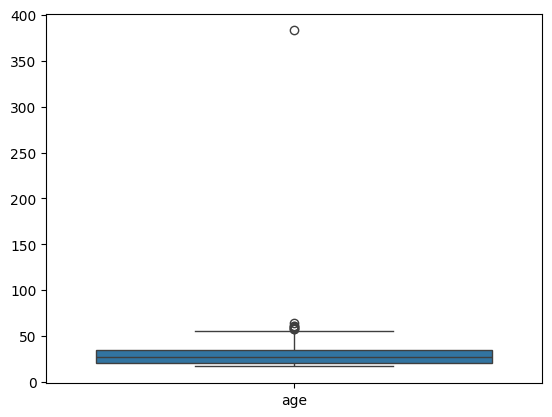

In [5]:
sns.boxplot([df.age])

In [6]:
df[df['age']==df['age'].max()]

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
52,1,0,0,0,0,0,0,0,0,0,383.0,f,Pasifika,no,no,New Zealand,no,1,18 and more,Self,NO


In [7]:
if 52 in df.index:
    # Drop the row with index 52
    df.drop(index=52, inplace=True)
    
    # Reset the index
    df.reset_index(drop=True, inplace=True)
else:
    print("Index '52' does not exist in the DataFrame.")

In [8]:
df['age'] = df['age'].fillna(np.round(df['age'].mean(), 0))

In [9]:
pd.DataFrame(df.isnull().sum(), columns=["Missing Values"])

,Missing Values
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0
A10_Score,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 703 entries, 0 to 702
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         703 non-null    int64  
 1   A2_Score         703 non-null    int64  
 2   A3_Score         703 non-null    int64  
 3   A4_Score         703 non-null    int64  
 4   A5_Score         703 non-null    int64  
 5   A6_Score         703 non-null    int64  
 6   A7_Score         703 non-null    int64  
 7   A8_Score         703 non-null    int64  
 8   A9_Score         703 non-null    int64  
 9   A10_Score        703 non-null    int64  
 10  age              703 non-null    float64
 11  gender           703 non-null    object 
 12  ethnicity        703 non-null    object 
 13  jundice          703 non-null    object 
 14  austim           703 non-null    object 
 15  contry_of_res    703 non-null    object 
 16  used_app_before  703 non-null    object 
 17  result          

<h2>5. Replace the invalid values</h2>

In [11]:
for col in df.select_dtypes('object').columns:
    print(f'column names :- {col}\n')
    print(f'Unique values: \n {df[col].unique()} \n')
    print('-----------------------------------------------------------------------')

column names :- gender

Unique values: 
 ['f' 'm'] 

-----------------------------------------------------------------------
column names :- ethnicity

Unique values: 
 ['White-European' 'Latino' '?' 'Others' 'Black' 'Asian' 'Middle Eastern '
 'Pasifika' 'South Asian' 'Hispanic' 'Turkish' 'others'] 

-----------------------------------------------------------------------
column names :- jundice

Unique values: 
 ['no' 'yes'] 

-----------------------------------------------------------------------
column names :- austim

Unique values: 
 ['no' 'yes'] 

-----------------------------------------------------------------------
column names :- contry_of_res

Unique values: 
 ['United States' 'Brazil' 'Spain' 'Egypt' 'New Zealand' 'Bahamas'
 'Burundi' 'Austria' 'Argentina' 'Jordan' 'Ireland' 'United Arab Emirates'
 'Afghanistan' 'Lebanon' 'United Kingdom' 'South Africa' 'Italy'
 'Pakistan' 'Bangladesh' 'Chile' 'France' 'China' 'Australia' 'Canada'
 'Saudi Arabia' 'Netherlands' 'Romania' 'Swe

Replace the Relation with '?' values as maximum frequency mode

In [12]:
df['relation'] = df['relation'].replace('?',df['relation'].mode()[0])
df['relation'].unique()

array(['Self', 'Parent', 'Health care professional', 'Relative', 'Others'],
      dtype=object)

Replace the ethnicity values with others value

In [13]:
df['ethnicity'] = df['ethnicity'].replace('?','Others')
df['ethnicity'] = df['ethnicity'].replace('others','Others')
df['ethnicity'].unique()

array(['White-European', 'Latino', 'Others', 'Black', 'Asian',
       'Middle Eastern ', 'Pasifika', 'South Asian', 'Hispanic',
       'Turkish'], dtype=object)

<h2>6. Visualization</h2>

Text(0, 0.5, 'No. of peoples')

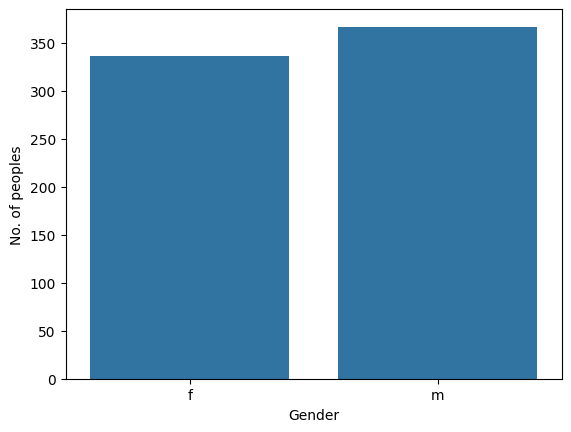

In [14]:
sns.countplot(data=df,x='gender')
plt.xlabel('Gender')
plt.ylabel('No. of peoples')

Text(0.5, 1.0, 'No. of People accepted they have Autism condition')

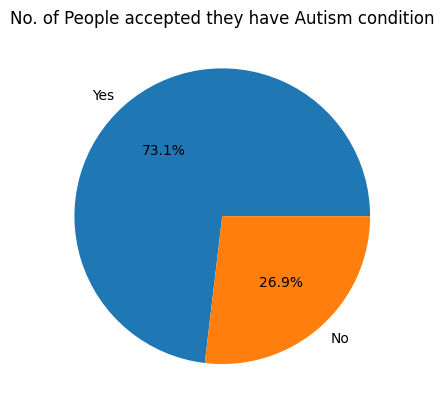

In [15]:
df_gender = df['Class/ASD'].value_counts()
plt.pie(df_gender,labels=['Yes','No'],autopct='%1.1f%%')
plt.title('No. of People accepted they have Autism condition')

C:\Users\RAKSHAK\AppData\Local\Temp\ipykernel_14128\3061134266.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(coun,fontsize = 5,fontweight='bold')


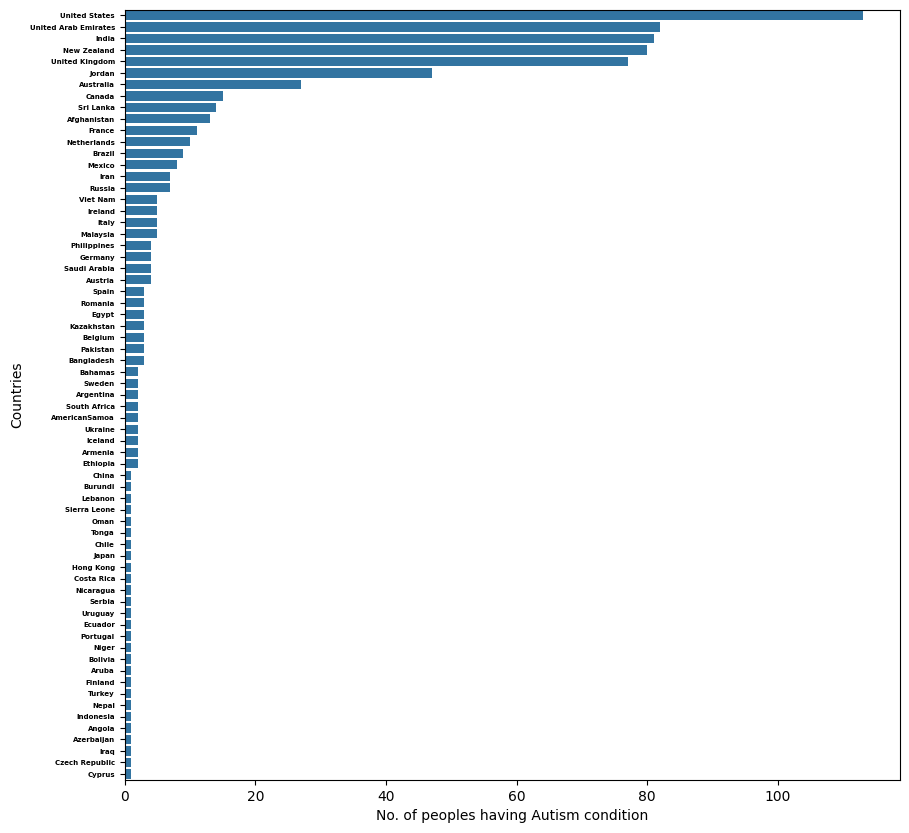

In [16]:
df_country = df['contry_of_res'].value_counts()
d = dict(df_country)
coun = []
ind = []
for i,j in d.items():
    coun.append(i)
    ind.append(j)

plt.figure(figsize=(10,10))
ax = sns.barplot(x=ind,y=coun)
ax.set_yticklabels(coun,fontsize = 5,fontweight='bold')
plt.xlabel('No. of peoples having Autism condition')
plt.ylabel('Countries')
plt.show()

<h2>7. Pre-processing Data for Classification</h2>

In [17]:
df.drop(['age_desc','used_app_before'], axis=1, inplace=True)

In [18]:
x = df.drop(['Class/ASD'],axis=1)
y = df['Class/ASD']

In [19]:
x.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,result,relation
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,6,Self
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,5,Self
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,8,Parent
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,6,Self
4,1,0,0,0,0,0,0,1,0,0,40.0,f,Others,no,no,Egypt,2,Self


In [20]:
X = pd.get_dummies(x).astype(int)
Y = y.replace({"YES": int(1), "NO": int(0)})

C:\Users\RAKSHAK\AppData\Local\Temp\ipykernel_14128\1071467741.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = y.replace({"YES": int(1), "NO": int(0)})


In [21]:
X.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'result',
       'gender_f', 'gender_m', 'ethnicity_Asian', 'ethnicity_Black',
       'ethnicity_Hispanic', 'ethnicity_Latino', 'ethnicity_Middle Eastern ',
       'ethnicity_Others', 'ethnicity_Pasifika', 'ethnicity_South Asian',
       'ethnicity_Turkish', 'ethnicity_White-European', 'jundice_no',
       'jundice_yes', 'austim_no', 'austim_yes', 'contry_of_res_Afghanistan',
       'contry_of_res_AmericanSamoa', 'contry_of_res_Angola',
       'contry_of_res_Argentina', 'contry_of_res_Armenia',
       'contry_of_res_Aruba', 'contry_of_res_Australia',
       'contry_of_res_Austria', 'contry_of_res_Azerbaijan',
       'contry_of_res_Bahamas', 'contry_of_res_Bangladesh',
       'contry_of_res_Belgium', 'contry_of_res_Bolivia',
       'contry_of_res_Brazil', 'contry_of_res_Burundi', 'contry_of_res_Canada',
       'contry_of_res_Chile', 'contry_of_res

In [22]:
Y.head()

0    0
1    0
2    1
3    0
4    0
Name: Class/ASD, dtype: int64

In [23]:
X_train1,X_test1,Y_train1,Y_test1 = train_test_split(X,Y,test_size=0.25, random_state=42)

In [24]:
X_train1.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,gender_f,gender_m,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Latino,ethnicity_Middle Eastern,ethnicity_Others,ethnicity_Pasifika,ethnicity_South Asian,ethnicity_Turkish,ethnicity_White-European,jundice_no,jundice_yes,austim_no,austim_yes,contry_of_res_Afghanistan,contry_of_res_AmericanSamoa,contry_of_res_Angola,contry_of_res_Argentina,contry_of_res_Armenia,contry_of_res_Aruba,contry_of_res_Australia,contry_of_res_Austria,contry_of_res_Azerbaijan,contry_of_res_Bahamas,contry_of_res_Bangladesh,contry_of_res_Belgium,contry_of_res_Bolivia,contry_of_res_Brazil,contry_of_res_Burundi,contry_of_res_Canada,contry_of_res_Chile,contry_of_res_China,contry_of_res_Costa Rica,contry_of_res_Cyprus,contry_of_res_Czech Republic,contry_of_res_Ecuador,contry_of_res_Egypt,contry_of_res_Ethiopia,contry_of_res_Finland,contry_of_res_France,contry_of_res_Germany,contry_of_res_Hong Kong,contry_of_res_Iceland,contry_of_res_India,contry_of_res_Indonesia,contry_of_res_Iran,contry_of_res_Iraq,contry_of_res_Ireland,contry_of_res_Italy,contry_of_res_Japan,contry_of_res_Jordan,contry_of_res_Kazakhstan,contry_of_res_Lebanon,contry_of_res_Malaysia,contry_of_res_Mexico,contry_of_res_Nepal,contry_of_res_Netherlands,contry_of_res_New Zealand,contry_of_res_Nicaragua,contry_of_res_Niger,contry_of_res_Oman,contry_of_res_Pakistan,contry_of_res_Philippines,contry_of_res_Portugal,contry_of_res_Romania,contry_of_res_Russia,contry_of_res_Saudi Arabia,contry_of_res_Serbia,contry_of_res_Sierra Leone,contry_of_res_South Africa,contry_of_res_Spain,contry_of_res_Sri Lanka,contry_of_res_Sweden,contry_of_res_Tonga,contry_of_res_Turkey,contry_of_res_Ukraine,contry_of_res_United Arab Emirates,contry_of_res_United Kingdom,contry_of_res_United States,contry_of_res_Uruguay,contry_of_res_Viet Nam,relation_Health care professional,relation_Others,relation_Parent,relation_Relative,relation_Self
176,0,0,1,1,1,0,0,1,1,1,29,6,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
223,1,1,1,1,1,1,1,0,1,1,21,9,1,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
213,1,1,1,1,0,0,0,0,0,1,42,5,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
239,1,0,0,1,1,0,1,1,0,0,21,5,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
182,0,0,1,1,1,0,0,0,0,1,34,4,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [25]:
print("Dataset with testsize of 25%")
print(f"Shape of X Training dataset = {np.shape(X_train1)}")
print(f"Shape of Y Training dataset = {np.shape(Y_train1)}")
print(f"Shape of X Testing dataset = {np.shape(X_test1)}")
print(f"Shape of Y Testing dataset = {np.shape(Y_test1)}\n")

Dataset with testsize of 25%
Shape of X Training dataset = (527, 100)
Shape of Y Training dataset = (527,)
Shape of X Testing dataset = (176, 100)
Shape of Y Testing dataset = (176,)



In [26]:
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()

<h2>8. Logistic Regresseion</h2>

Best Parameters for Logistic Regression: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV Accuracy: 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00        56

    accuracy                           1.00       176
   macro avg       1.00      1.00      1.00       176
weighted avg       1.00      1.00      1.00       176

Mean squared error of logistic regression = 0.0000
R-squared = 1.0000

ROC-AUC Score = 1.0000


C:\Users\RAKSHAK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\RAKSHAK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


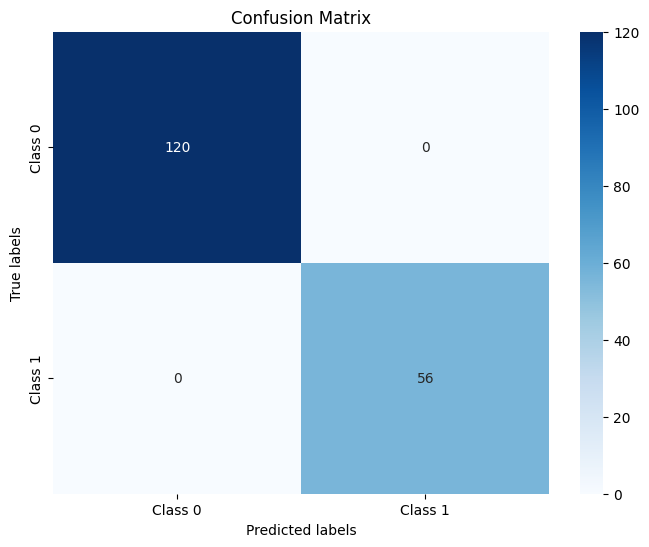

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model as lm

# Create pipeline with StandardScaler
pipeline1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.LogisticRegression(max_iter=1000, random_state=42))
])

# Define parameter grid
param_grid_log = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid_log = GridSearchCV(pipeline1, param_grid=param_grid_log, cv=cv, scoring='accuracy', n_jobs=-1)
grid_log.fit(X_train1, Y_train1)

best_log = grid_log.best_estimator_
print("Best Parameters for Logistic Regression:", grid_log.best_params_)
print(f"Best CV Accuracy: {grid_log.best_score_:.4f}")

prediction_log = best_log.predict(X_test1)
print("\nClassification Report (Test Set):")
print(classification_report(Y_test1, prediction_log))

mse_log1 = mean_squared_error(Y_test1, prediction_log)
r2_log1 = r2_score(Y_test1, prediction_log)

print(f"Mean squared error of logistic regression = {mse_log1:.4f}")
print(f"R-squared = {r2_log1:.4f}\n")

# Calculate ROC-AUC
prob_log = best_log.predict_proba(X_test1)[:, 1]
auc_log = roc_auc_score(Y_test1, prob_log)
print(f"ROC-AUC Score = {auc_log:.4f}")

plot_confusion_matrix(Y_test1, prediction_log, classes=['Class 0', 'Class 1'])

<h2>9. Support Vector Machine</h2>

Best Parameters for SVM: {'model__C': 1, 'model__gamma': 0.001, 'model__kernel': 'linear'}
Best CV Accuracy: 0.9868

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00        56

    accuracy                           1.00       176
   macro avg       1.00      1.00      1.00       176
weighted avg       1.00      1.00      1.00       176

Mean squared error of SVC = 0.0000
R-squared = 1.0000

ROC-AUC Score = 1.0000


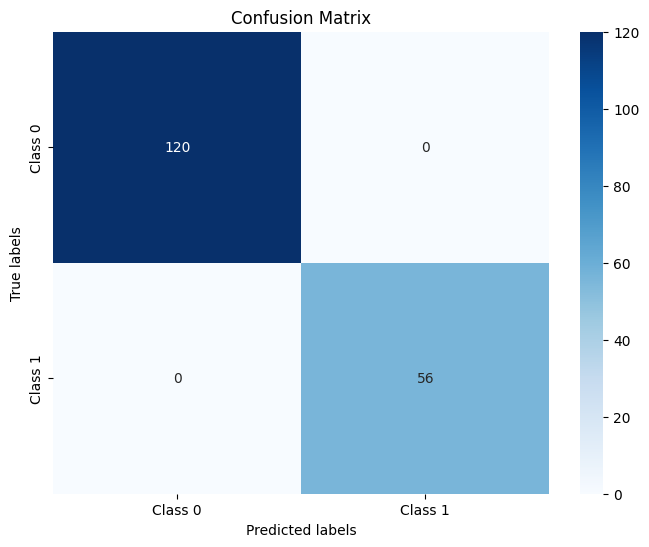

In [28]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define pipeline with scaler for SVM
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(probability=True, random_state=42))
])

# Define parameter grid
param_grid_svm = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': [0.001, 0.01, 0.1, 1],
    'model__kernel': ['rbf', 'linear']
}

# Grid Search
grid_svm = GridSearchCV(pipeline_svm, param_grid=param_grid_svm, cv=cv, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train1, Y_train1)

best_svm = grid_svm.best_estimator_
print("Best Parameters for SVM:", grid_svm.best_params_)
print(f"Best CV Accuracy: {grid_svm.best_score_:.4f}")

prediction_svm = best_svm.predict(X_test1)
print("\nClassification Report (Test Set):")
print(classification_report(Y_test1, prediction_svm))

mse_svm = mean_squared_error(Y_test1, prediction_svm)
r2_svm = r2_score(Y_test1, prediction_svm)

print(f"Mean squared error of SVC = {mse_svm:.4f}")
print(f"R-squared = {r2_svm:.4f}\n")

# Calculate ROC-AUC
prob_svm = best_svm.predict_proba(X_test1)[:, 1]
auc_svm = roc_auc_score(Y_test1, prob_svm)
print(f"ROC-AUC Score = {auc_svm:.4f}")

plot_confusion_matrix(Y_test1, prediction_svm, classes=['Class 0', 'Class 1'])

<h2>10. Random Forest Classification</h2>

Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Accuracy: 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00        56

    accuracy                           1.00       176
   macro avg       1.00      1.00      1.00       176
weighted avg       1.00      1.00      1.00       176

Mean squared error of Random Forest = 0.0000
R-squared = 1.0000

ROC-AUC Score = 1.0000


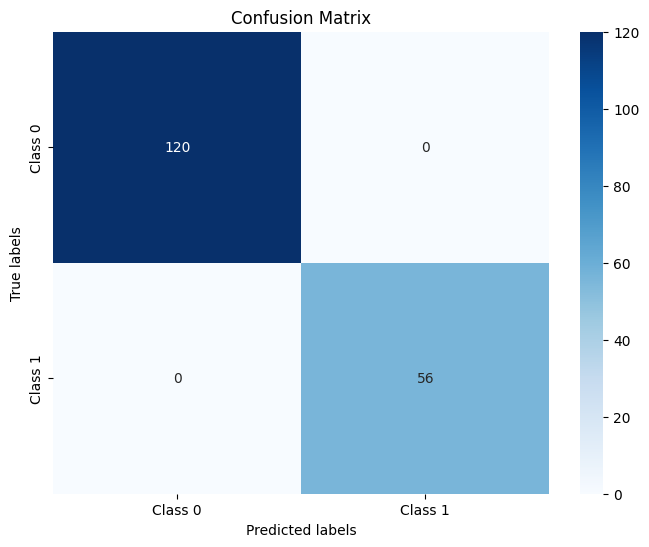

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Define Random Forest Classifier
model_rfc = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid_rfc = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search
grid_rfc = GridSearchCV(model_rfc, param_grid=param_grid_rfc, cv=cv, scoring='accuracy', n_jobs=-1)
grid_rfc.fit(X_train1, Y_train1)

best_rfc = grid_rfc.best_estimator_
print("Best Parameters for Random Forest:", grid_rfc.best_params_)
print(f"Best CV Accuracy: {grid_rfc.best_score_:.4f}")

prediction_rfc = best_rfc.predict(X_test1)
print("\nClassification Report (Test Set):")
print(classification_report(Y_test1, prediction_rfc))

mse_rfc = mean_squared_error(Y_test1, prediction_rfc)
r2_rfc = r2_score(Y_test1, prediction_rfc)

print(f"Mean squared error of Random Forest = {mse_rfc:.4f}")
print(f"R-squared = {r2_rfc:.4f}\n")

# Calculate ROC-AUC
prob_rfc = best_rfc.predict_proba(X_test1)[:, 1]
auc_rfc = roc_auc_score(Y_test1, prob_rfc)
print(f"ROC-AUC Score = {auc_rfc:.4f}")

plot_confusion_matrix(Y_test1, prediction_rfc, classes=['Class 0', 'Class 1'])

<h2>10.5 XGBoost Classifier</h2>

Best Parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best CV Accuracy: 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00        56

    accuracy                           1.00       176
   macro avg       1.00      1.00      1.00       176
weighted avg       1.00      1.00      1.00       176

Mean squared error of XGBoost = 0.0000
R-squared = 1.0000

ROC-AUC Score = 1.0000


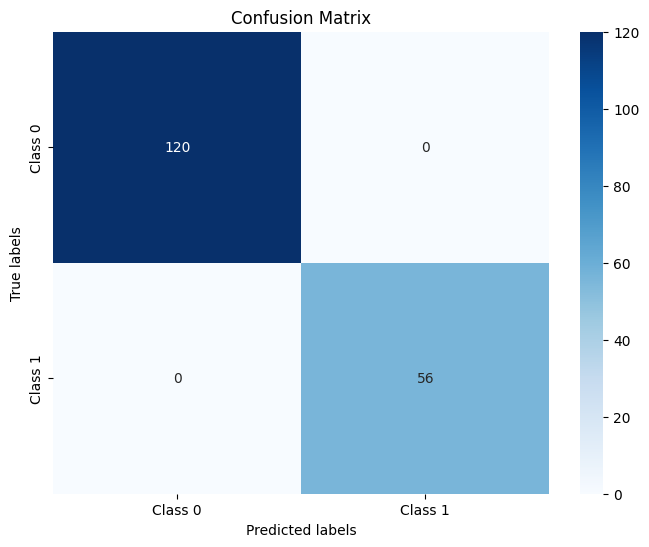

In [30]:
# Define XGBoost Classifier
model_xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# Define parameter grid
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Grid Search
grid_xgb = GridSearchCV(model_xgb, param_grid=param_grid_xgb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train1, Y_train1)

best_xgb = grid_xgb.best_estimator_
print("Best Parameters for XGBoost:", grid_xgb.best_params_)
print(f"Best CV Accuracy: {grid_xgb.best_score_:.4f}")

prediction_xgb = best_xgb.predict(X_test1)
print("\nClassification Report (Test Set):")
print(classification_report(Y_test1, prediction_xgb))

mse_xgb = mean_squared_error(Y_test1, prediction_xgb)
r2_xgb = r2_score(Y_test1, prediction_xgb)

print(f"Mean squared error of XGBoost = {mse_xgb:.4f}")
print(f"R-squared = {r2_xgb:.4f}\n")

# Calculate ROC-AUC
prob_xgb = best_xgb.predict_proba(X_test1)[:, 1]
auc_xgb = roc_auc_score(Y_test1, prob_xgb)
print(f"ROC-AUC Score = {auc_xgb:.4f}")

plot_confusion_matrix(Y_test1, prediction_xgb, classes=['Class 0', 'Class 1'])

<h2>10.6 Model Performance Comparison & ROC Curves</h2>

Model Comparison on Test Set:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0
3,XGBoost,1.0,1.0,1.0,1.0,1.0


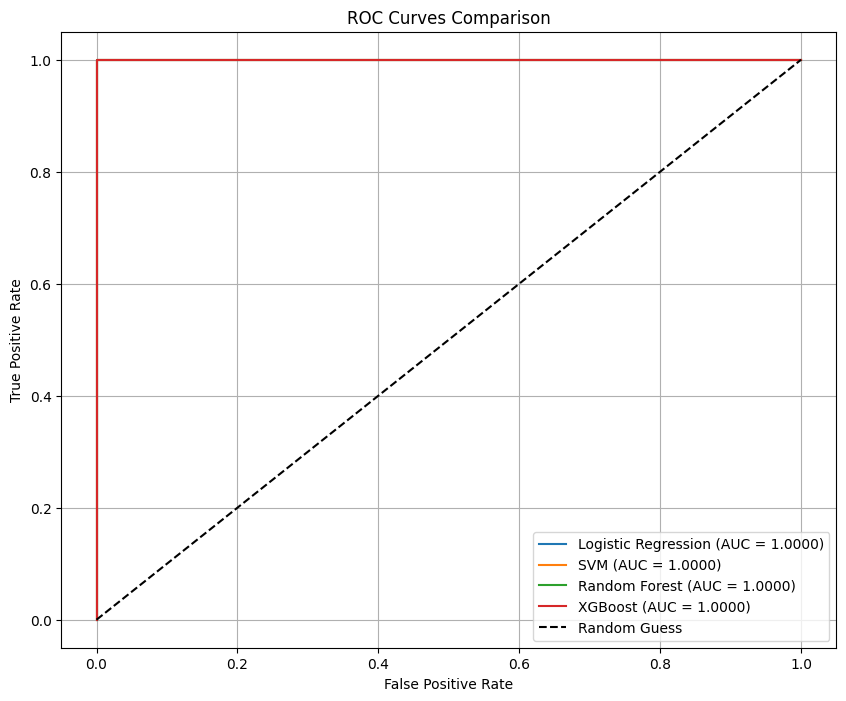

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Logistic Regression': (best_log, prediction_log, prob_log),
    'SVM': (best_svm, prediction_svm, prob_svm),
    'Random Forest': (best_rfc, prediction_rfc, prob_rfc),
    'XGBoost': (best_xgb, prediction_xgb, prob_xgb)
}

comparison_data = []

for name, (model, pred, prob) in models.items():
    acc = accuracy_score(Y_test1, pred)
    prec = precision_score(Y_test1, pred, average='weighted')
    rec = recall_score(Y_test1, pred, average='weighted')
    f1 = f1_score(Y_test1, pred, average='weighted')
    auc = roc_auc_score(Y_test1, prob)
    comparison_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

df_comparison = pd.DataFrame(comparison_data)
print("Model Comparison on Test Set:")
display(df_comparison)

# Plot ROC Curves
plt.figure(figsize=(10, 8))
for name, (model, pred, prob) in models.items():
    fpr, tpr, _ = roc_curve(Y_test1, prob)
    auc = roc_auc_score(Y_test1, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

<h2>11. Results</h2>

<h2>From above observation we found that model accuracy across the different splits highlight the critical role of data splitting strategies in enhancing predictive performance and capturing the underlying patterns in the data.
Model 3, with the lowest mean squared error and highest R-squared value have more refined subsets of data lead to better model performance, emphasizing the significance of data preprocessing and feature selection in predictive modeling.</h2>